In [1]:
import sys
sys.path.append('/home/semik/projekty/noncanonical_introns/')

import pathlib
pathlib.Path().absolute()

import introns
import intron_comparison
from collections import defaultdict
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from copy import copy
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from math import sqrt
import csv

In [5]:
path="/mnt/archive/euglena_genomy/"
path2="/home/semik/projekty/noncanonical_introns/"

genom_EG=path+"gracilis/gracilis_dbg2olc.fasta"
geny_EG=path+"gracilis/gracilis_stringtie_strand_informed.gtf"
geny_EG_rev=path2+"gracilis_stringtie_strand_informed_reversed.gtf"

genom_EH=path+'hiemalis/hiemalis_rascaf.fasta'
geny_EH=path+'hiemalis/stringtie_strand_informed3.gtf'
geny_EH_rev=path2+"stringtie_strand_informed3_reversed.gtf"

genom_EL=path+'longa/longa_rascaf.fasta'
geny_EL=path+'longa/longa_stringtie_strand_informed.gtf'
geny_EL_rev=path2+"longa_stringtie_strand_informed_reversed.gtf"

genom_bugtest = '/home/semik/projekty/noncanonical_introns/introny_fasty/bugtest.fasta'
geny_bugtest = '/home/semik/projekty/noncanonical_introns/introny_fasty/bugtest.gtf'
geny_bugtest_rev = '/home/semik/projekty/noncanonical_introns/introny_fasty/bugtest_reversed.gtf'

In [6]:
def create_both(genome,genes,genes_rev):
    genome_eug, genes_eug = introns.create_genes(genome,genes)
    genome_eug,genes_eug_rev = introns.create_genes(genome,genes_rev)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
    return genome_eug,genes_eug, genes_eug_rev
    
def stats(genome_eug,genes_eug):  
    conv_count=0
    nconv_count=0
    both_count=0
    all_count=0
    non_count=0
    conventional_classes=[0,0,0,0,0,0,0,0]
    nonconventional_classes=[0,0,0,0,0,0,0,0,0]

    for name, gene in list(genes_eug.items()):
        for intron in gene.introns:
            all_count+=1

            if intron.best_nonconv_var and not intron.best_conv_var:
                nonconventional_classes[intron.best_nonconv_var-1]+=1
                nconv_count+=1
            elif intron.best_conv_var and not intron.best_nonconv_var:
                conventional_classes[intron.best_conv_var-1]+=1
                conv_count+=1
            elif intron.best_conv_var and intron.best_nonconv_var:
                both_count+=1
            else:
                non_count+=1
    print("\nKonwencjonalne: %d, niekonwencjonalne: %d, oba: %d inne: %d, wszystkie: %d" %(conv_count,nconv_count, both_count,non_count,all_count))
    return conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count

In [16]:
'''genome_bugtest, genes_bugtest, genes_bugtest_rev = create_both(genom_bugtest, geny_bugtest, geny_bugtest_rev)
genome_EG, genes_EG, genes_EG_rev = create_both(genom_EG, geny_EG, geny_EG_rev)
genome_EH, genes_EH, genes_EH_rev = create_both(genom_EH, geny_EH, geny_EH_rev)
genome_EL, genes_EL, genes_EL_rev = create_both(genom_EL, geny_EL, geny_EL_rev)'''

#genome_bugtest, genes_bugtest = introns.create_genes(genom_bugtest, geny_bugtest)
genome_EG, genes_EG = introns.create_genes(genom_EG, geny_EG)
genome_EH, genes_EH = introns.create_genes(genom_EH, geny_EH)genome_EL, genes_EL = introns.create_genes(genom_EL, geny_EL)

STRG.8632.1 scaffold_5860 36362 36570


In [19]:
wszystkie=0
for species, genome, genes in [("gracilis",genome_EG, genes_EG), ("hiemalis", genome_EH, genes_EH), ("longa",genome_EL, genes_EL)]:
    suma_all=0
    suma_podst=0
    suma_var=0
    for name,gene in genes.items():
        for intron in gene.introns:
            suma_all+=1
            suma_podst+=1
            for var in intron.variations:
                suma_all+=1
                suma_var+=1
    print(species, suma_all==suma_podst+suma_var, suma_podst+suma_var, suma_podst)
    wszystkie+=suma_all
print(wszystkie)

gracilis True 2686457 1015687
hiemalis True 1846695 673990
longa True 581251 221271
5114403


In [19]:
Ms=[]
classes=[]
for name,genome,genes,genes_rev in [("bugtest", genome_bugtest, genes_bugtest, genes_bugtest_rev), ("gracilis",genome_EG, genes_EG, genes_EG_rev), ("hiemalis", genome_EH, genes_EH, genes_EH_rev), ("longa",genome_EL, genes_EL, genes_EL_rev)]:
    conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count = stats(genome, genes)
    conventional_classes_rev, nonconventional_classes_rev, conv_count_rev,nconv_count_rev, both_count_rev,non_count_rev,all_count_rev = stats(genome, genes_rev)
    M=[name, ["typ","konwencjonalne","niekonwencjonalne","oba","inne","wszystkie"],["dobre",conv_count,nconv_count, both_count,non_count,all_count],["reversed",conv_count_rev,nconv_count_rev, both_count_rev,non_count_rev,all_count_rev]]
    Ms.append(M)
    classes.append([[name, genes, genes_rev, all_count],[conventional_classes, nonconventional_classes], [conventional_classes_rev, nonconventional_classes_rev]])

In [20]:
def liczenie_ocen_genow(genes, genes_rev, conv_classes, nonconv_classes):
    ulamki_niekonw=[i/all_count for i in nonconv_classes]
    punktacja_niekonw = [1/sqrt(sum(ulamki_niekonw[:a+1])) for a in range(len(nonconv_classes))]
    
    kolejnosc=[j[0] for j in sorted(wagi.items(), key=lambda i: i[1])][1:]
    conv_classes=[conv_classes[k-1] for k in kolejnosc]
    ulamki_konw = [i/all_count for i in conv_classes]
    punktacja_konw = [1/sqrt(sum(ulamki_konw[:a+1])) for a in range(len(conv_classes))]
    #punktacja_konw = [1/sum(ulamki_konw[:a+1]) for a in range(len(conv_classes))]
    #punktacja_konw = [1/sum([sqrt(u) for u in ulamki_konw][:a+1]) for a in range(len(conv_classes))]
    zlegeny,wszystkiegeny=[],[]
    geny1, geny2= list(genes.items()), list(genes_rev.items())
    
    for i in range(len(geny1)):
        punkty_basic,punkty_rev = 0, 0
        ilosc_intronow_genu=len(geny1[i][1].introns)
        for j in range(ilosc_intronow_genu):
            
            int1,int2=geny1[i][1].introns[j], geny2[i][1].introns[j]
            oceny1, oceny2 = [], []
            if int1.best_conv_var: oceny1.append(punktacja_konw[int1.best_conv_var-1])
            if int2.best_conv_var: oceny2.append(punktacja_konw[int1.best_conv_var-1])
            if int1.best_nonconv_var: oceny1.append(punktacja_niekonw[int1.best_nonconv_var-1])
            if int2.best_nonconv_var: oceny2.append(punktacja_niekonw[int2.best_nonconv_var-1])
            
            punkty_basic = max(oceny1) if oceny1 else 0
            punkty_rev= max(oceny2) if oceny2 else 0
                
        if ilosc_intronow_genu: ocena=(punkty_basic-punkty_rev)/ilosc_intronow_genu
        else: ocena=0
        if ocena<0:
            zlegeny.append((geny1[i][0], ocena))
        wszystkiegeny.append((geny1[i][1],geny2[i][1], ocena))
    return zlegeny,wszystkiegeny

In [21]:
wagi={0:0, 1:1, 2:3, 3:5, 4:7, 5:2, 6:4, 7:6, 8:8}
introny_do_analizy=[]
for species in classes[1:]:
    nazwa=species[0][0]
    print("\n%s" %nazwa)
    all_count=species[0][3]
    conv_classes, nonconv_classes = species[1]
    
    geny_for, geny_rev = species[0][1], species[0][2]
    zlegeny,wszystkiegeny=liczenie_ocen_genow(geny_for, geny_rev, conv_classes, nonconv_classes)
    print(len(zlegeny))
    
    geny_forward = [i[0] for i in wszystkiegeny if i[2]>0.1]
    geny_reverse = [i[1] for i in wszystkiegeny if i[2]<-0.1]
    
    lista_intronow = [intron for i in [gen.introns for gen in geny_forward] for intron in i if intron.best_nonconv_var] + [intron for i in [gen.introns for gen in geny_reverse] for intron in i if intron.best_nonconv_var] 
    introny_do_analizy.append((nazwa, lista_intronow))
    print(len(lista_intronow))


gracilis
68196
118227

hiemalis
10655
56790

longa
9031
20801


from itertools import groupby

def find_kgrams(string, k):
    kgrams = sorted(
        string[j:j+k]
            for i in range(k)
                for j in range(i, (len(string) - i) // k * k, k)
    )
    groups = [(k, len(list(g))) for k, g in groupby(kgrams)]
    return sorted(groups, key=lambda i: i[1], reverse=True)

for species in introny_do_analizy:
    nazwa, lista_intronow = species
    kmers=[]
    for k in range(3,19): #3,21
        kmers_dict = {}
        for intron in lista_intronow:
            kmers = find_kgrams(intron.sequence, k)
            for kmer in kmers:
                if kmer[0] in kmers_dict:
                    kmers_dict[kmer[0]]+=kmer[1]
                else: kmers_dict[kmer[0]]=kmer[1]
        kmers_sorted=sorted(kmers_dict.items(), key=lambda i: i[1], reverse=True)
        print('\nGatunek: %s, k=%d:' %(nazwa, k), kmers_sorted[:6])

In [ ]:


print("Punktacja za intron o danej klasie: ilosc intronow w danej klasie w podstawowym kierunku / ilosc wszystkich intronow")
#species=[[name, genes, genes_rev, all_count],[conventional_classes, nonconventional_classes], [conventional_classes_rev, nonconventional_classes_rev]]
for species in classes[1:]:
    nazwa=species[0][0]
    print("\n%s" %nazwa)
    all_count=species[0][3]
    conv_classes, nonconv_classes = species[1]
    geny_for, geny_rev = species[0][1], species[0][2]
    zlegeny,wszystkiegeny=liczenie_ocen_genow(geny_for, geny_rev, conv_classes, nonconv_classes)
    print("ilosc zlych genow: %d z wszystkich %d (%d %%)" %(len(zlegeny), len(geny_for), len(zlegeny)/len(geny_for)*100))

    
    oceny_zle=[i[1] for i in zlegeny]
    oceny_all=[i[2] for i in wszystkiegeny]
    conv_for, conv_rev, conv_both, conv_none = [], [], [], [] #listy z genami, ktore maja tylko introny w dana strone
    for gen in wszystkiegeny:
        forward,reverse=False,False
        for intron in gen[0].introns:
            if intron.best_conv_var:
                forward=True
                break
        for intron in gen[1].introns:
            if intron.best_conv_var:
                reverse=True
                break
        if forward and reverse: conv_both.append(gen[2])
        elif forward and not reverse: conv_for.append(gen[2])
        elif not forward and reverse: conv_rev.append(gen[2])
        else: conv_none.append(gen[2])
            
    
    fig, axes=plt.subplots(nrows=3, ncols=2)
    
    n, bins, patches = axes[0,0].hist(x=oceny_all, bins=30, color='orange')
    axes[0,0].set_title('Wszystkie geny')
    axes[0,0].set_xlim
    
    axes[0,1].hist(x=oceny_zle, bins=25, color='gold')
    axes[0,1].set_title('Złe geny')
    
    axes[1,0].hist(x=conv_for, bins=25, color='mediumblue')
    axes[1,0].set_title('Z konwencjonalnymi tylko forward')
    
    axes[1,1].hist(x=conv_rev, bins=25, color='slateblue')
    axes[1,1].set_title('Z konwencjonalnymi tylko reversed')
    
    axes[2,0].hist(x=conv_both, bins=25, color='green')
    axes[2,0].set_title('Z konwencjonalnymi w obie strony')
    
    axes[2,1].hist(x=conv_none, bins=25, color='red')
    axes[2,1].set_title('Bez intronów konwencjonalnych')
    
    listaslupkow=sorted([patches[i].get_height() for i in range(len(patches))])
    for i in range(3):
        for j in range(2):
            axes[i,j].set_ylim(0,listaslupkow[-2]*1.01)
    fig.tight_layout()
    plt.show()
    
    '''lamany wykres 1'''
    f, (ax11, ax21) = plt.subplots(2,1,sharex = True)
    n1, bins1, patches1 = ax11.hist(x=oceny_all, bins=50, color='orange')
    listaslupkow1=copy(sorted([patches1[i].get_height() for i in range(len(patches1))]))
    ax21.hist(x=oceny_all, bins=50, color='orange')
    ax11.set_ylim(listaslupkow1[-1]*0.95, listaslupkow1[-1]*1.01)
    ax21.set_ylim(0, listaslupkow1[-2]*1.01)
    ax11.set_title('Wszystkie geny')
    
    '''d = 0  # how big to make the diagonal lines in axes coordinates
    # arguments to pass to plot, just so we don't keep repeating them
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax11.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
    ax11.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax21.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
    ax21.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal'''
    
    ax11.spines['bottom'].set_visible(False)
    ax21.spines['top'].set_visible(False)
    ax11.xaxis.tick_top()
    ax11.tick_params(labeltop=False)  # don't put tick labels at the top
    ax21.xaxis.tick_bottom()
    plt.show()
    
    '''lamany wykres 4'''
    f, (ax14, ax24) = plt.subplots(2,1,sharex = True)    
    n4,bins4,patches4=ax14.hist(x=conv_none, bins=25, color='red')
    ax24.hist(x=conv_none, bins=25, color='red')
    ax14.set_title('Bez intronów konwencjonalnych')
    listaslupkow4=sorted([patches4[i].get_height() for i in range(len(patches4))])
    ax14.set_ylim(listaslupkow4[-1]*0.95, listaslupkow4[-1]*1.01)
    ax24.set_ylim(0, listaslupkow4[-2]*1.01)
    
    '''d = .015  # how big to make the diagonal lines in axes coordinates
    # arguments to pass to plot, just so we don't keep repeating them
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax14.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
    ax14.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax24.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
    ax24.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal'''
    
    ax14.spines['bottom'].set_visible(False)
    ax24.spines['top'].set_visible(False)
    ax14.xaxis.tick_top()
    ax14.tick_params(labeltop=False)  # don't put tick labels at the top
    ax24.xaxis.tick_bottom()
    plt.show()

In [23]:
for M in Ms:
    print("\n", M[0])
    print(tabulate(M[2:], headers=M[1]))


 bugtest
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre                    5                    6      0      11           22
reversed                 0                    3      0      19           22

 gracilis
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre               182332               124081   5619  714893      1015687
reversed            181901               122959   5750  716577      1015687

 hiemalis
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre               169923               136350   4990  372707       673990
reversed             43744                44002   4500  590744       673990

 longa
typ         konwencjonalne    niekonwencjonalne 

In [2]:
genome_bugtest, genes_bugtest, genes_bugtest_rev = create_both(genom_bugtest, geny_bugtest, geny_bugtest_rev)
genome_EG, genes_EG, create= create_both(genom_EG, geny_EG, geny_EG_rev)
genome_EH, genes_EH, genes_EH_rev = create_both(genom_EH, geny_EH, geny_EH_rev)
genome_EL, genes_EL, genes_EL_rev = create_both(genom_EL, geny_EL, geny_EL_rev)

klasy,counts=[],[]
for name,genome,genes in [("E. gracilis",genome_EG, genes_EG), ("E. hiemalis", genome_EH, genes_EH), ("E. longa",genome_EL, genes_EL)]:
#for name,genome,genes in [("gracilis reversed",genom_EG,geny_EG_rev), ("hiemalis reversed", genom_EH,geny_EH_rev), ("longa reversed",genom_EL,geny_EL_rev)]:
    conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count = stats(genome,genes)
    #print("\n",name,"\nKonwencjonalne: %d, niekonwencjonalne: %d, oba: %d inne: %d, wszystkie: %d" %(conv_count,nconv_count, both_count,non_count,all_count))
    klasy.append([name,[i/all_count for i in conventional_classes],[i/all_count for i in nonconventional_classes]])
    counts.append([name, conv_count/all_count,nconv_count/all_count, both_count/all_count,non_count/all_count,all_count])
'''
#klasy dla gatunki_introny_unmoved-onesided.fasta
plikfasta="./introny_fasty/gatunki_introny_unmoved-onesided.fasta" 
klasy,counts=[],[]
for name in ["E.gracilis","E.hiemalis","E.longa"]:
    conv_count,nconv_count, both_count,non_count,all_count=0,0,0,0,0
    conventional_classes,nonconventional_classes=[0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0]
    for record in SeqIO.parse(plikfasta, "fasta"):
        gat,typlisty,nconv_class,conv_class = record.description.split(" ")
        if gat!=name: continue
        nconv_class,conv_class = int(nconv_class),int(conv_class)
        all_count+=1
        if nconv_class: nonconventional_classes[nconv_class-1]+=1
        if conv_class: conventional_classes[conv_class-1]+=1
        
        if nconv_class and conv_class:
            both_count+=1
        elif nconv_class and not conv_class:
            nconv_count+=1
        elif not nconv_class and conv_class:
            conv_count+=1
        else:
            non_count+=1
    counts.append([name, conv_count/all_count,nconv_count/all_count, both_count/all_count,non_count/all_count,all_count])
    klasy.append([name,[i/all_count for i in conventional_classes],[i/all_count for i in nonconventional_classes]])
print(counts)
print(klasy)'''

NameError: name 'genome_EG' is not defined

In [ ]:
lista1=[i[1] for i in klasy]
data=[[j*100 for j in l] for l in lista1]
legenda=[i[0] for i in klasy]
X = np.arange(8)
fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
r1=ax.bar(X + 0.00, data[0], color = 'b', width = 0.25)
r2=ax.bar(X + 0.25, data[1], color = 'g', width = 0.25)
r3=ax.bar(X + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Klasy intronów konwencjonalnych')
ax.set_xlabel('Klasy konwencjonalne')
ax.set_ylabel('% intronów')
ax.set_xticks(X)
ax.set_xticklabels(('Klasa 1', 'Klasa 2', 'Klasa 3', 'Klasa 4', 'Klasa 5', 'Klasa 6', 'Klasa 7', 'Klasa 8'))
ax.legend(legenda)

In [1]:
lista1=[i[2] for i in klasy]
data=[[j*100 for j in l] for l in lista1]
'''legenda=[i[0] for i in klasy]
Y = np.arange(9)
fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
ax.bar(Y + 0.00, data[0], color = 'b', width = 0.25)
ax.bar(Y + 0.25, data[1], color = 'g', width = 0.25)
ax.bar(Y + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Klasy intronów niekonwencjonalnych')
ax.set_xlabel('Klasy niekonwencjonalne')
ax.set_ylabel('% intronów')
ax.set_xticks(Y)
ax.set_xticklabels(('Klasa 1', 'Klasa 2', 'Klasa 3', 'Klasa 4', 'Klasa 5', 'Klasa 6', 'Klasa 7', 'Klasa 8', 'Klasa 9'))
ax.legend(legenda)
plt.savefig("klasy_niekonwencjonalne.png")'''
with open('klasy_niekonwencjonalne.csv', 'w') as f:
    writer=csv.writer(f)
    writer.writerows(data)

NameError: name 'klasy' is not defined

[[17.39837174247578, 11.663238773362266, 0.553221612563713, 70.38516787159824], [24.471134586566567, 19.48990341102984, 0.7403670677606493, 55.29859493464294], [20.513759146024558, 12.048573920667417, 0.5500042933778037, 66.88766263993023]]


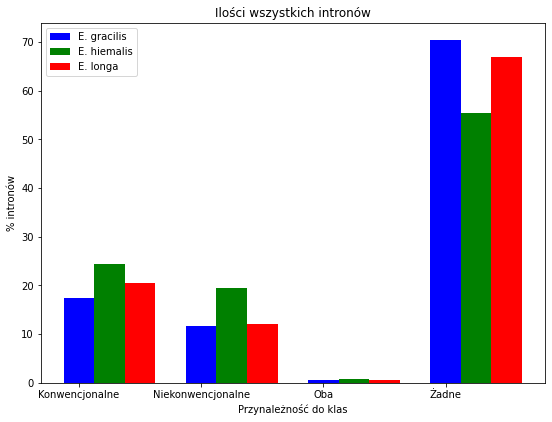

In [7]:
data=[[j*100 for j in l[1:-1]] for l in counts]
print(data)
labels=[i[0] for i in counts]
Z = np.arange(4)
fig = plt.figure(figsize=(7,5))
ax = fig.add_axes([0,0,1,1])
ax.bar(Z + 0.00, data[0], color = 'b', width = 0.25)
ax.bar(Z + 0.25, data[1], color = 'g', width = 0.25)
ax.bar(Z + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Ilości wszystkich intronów')
ax.set_xlabel('Przynależność do klas')
ax.set_ylabel('% intronów')
ax.set_xticks(Z)
ax.set_xticklabels(('Konwencjonalne','Niekonwencjonalne', 'Oba','Żadne'))
ax.legend(labels)